# Chapter 17 Representation Learning and Generative Learning Using Autoencoders and GANs

## 17.1 Efficient Data Representations

## 17.2 Performing PCA with an Undercomplete Linear Autoencoder

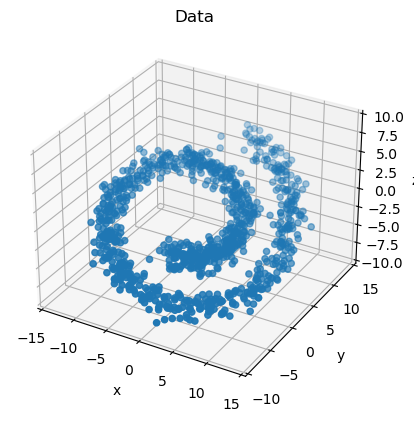

In [24]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from typing import Optional, Sequence


def plot_data(
    points: Sequence[Sequence[float]],
    colors: Optional[Sequence[float]] = None,
    title: str = "",
    **set_kwargs,
) -> None:
    points = np.asarray(points)
    n_points, dim = points.shape
    fig = plt.figure()
    ax = fig.add_subplot(projection="3d" if dim == 3 else None)
    ax.scatter(*points.T, c=colors)
    set_kwargs["xlabel"] = "x"
    set_kwargs["ylabel"] = "y"
    if dim == 3:
        set_kwargs["zlabel"] = "z"
    set_kwargs["title"] = title
    ax.set(**set_kwargs)


n_points = 1000
sr_points, sr_colors = datasets.make_swiss_roll(
    n_samples=n_points, noise=1, random_state=42
)
data = np.c_[sr_points[:, [0, 2]], np.zeros(n_points)]

theta1 = np.pi / 8
rot1 = np.array(
    [
        [np.cos(theta1), 0, np.sin(theta1)],
        [0, 1, 0],
        [-np.sin(theta1), 0, np.cos(theta1)],
    ]
)
theta2 = np.pi / 6
rot2 = np.array(
    [
        [1, 0, 0],
        [0, np.cos(theta2), -np.sin(theta1)],
        [0, np.sin(theta1), np.cos(theta2)],
    ]
)

data = data.dot(rot1.T).dot(rot2.T)
set_kwargs = {
    "xlim": [-15, 15],
    "ylim": [-10, 15],
    "zlim": [-10, 10],
}
plot_data(data, title="Data", **set_kwargs)

##### Autoencoder

In [25]:
import tensorflow as tf

encoder = tf.keras.models.Sequential([tf.keras.layers.Dense(units=2, input_dim=3)])
decoder = tf.keras.models.Sequential([tf.keras.layers.Dense(units=3, input_dim=2)])

autoencoder = tf.keras.models.Sequential(
    [
        encoder,
        decoder,
    ]
)

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_9 (Sequential)   (None, 2)                 8         
                                                                 
 sequential_10 (Sequential)  (None, 3)                 9         
                                                                 
Total params: 17
Trainable params: 17
Non-trainable params: 0
_________________________________________________________________


In [26]:
history = autoencoder.fit(data, data)
rec = autoencoder.predict(data)
codings = encoder.predict(data)

32/32 [==============================] - 0s 806us/step


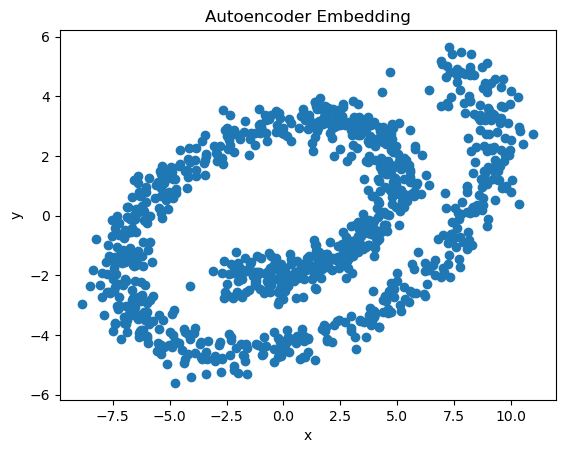

In [28]:
plot_data(points=codings, title="Autoencoder Embedding")

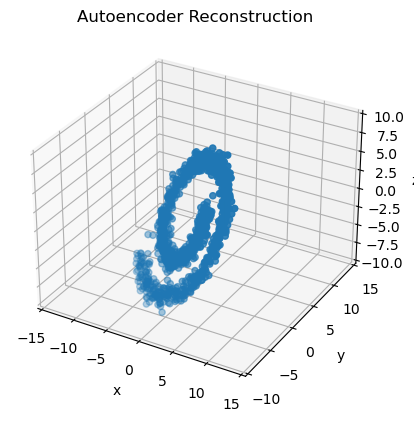

In [27]:
plot_data(points=rec, title="Autoencoder Reconstruction", **set_kwargs)

##### PCA

In [29]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=2)
pca.fit(data)

PCA(n_components=2)

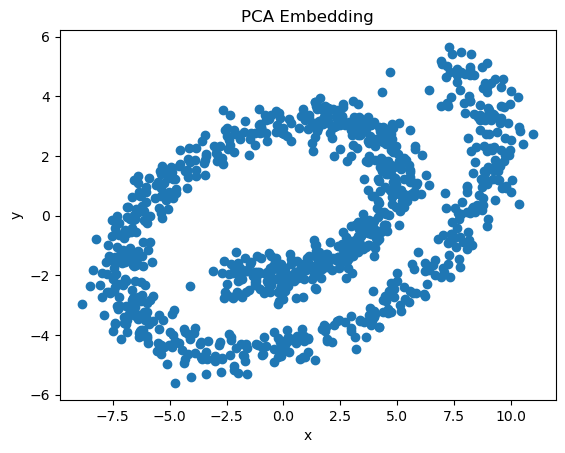

In [30]:
encoding = pca.transform(data)
plot_data(points=codings, title="PCA Embedding")

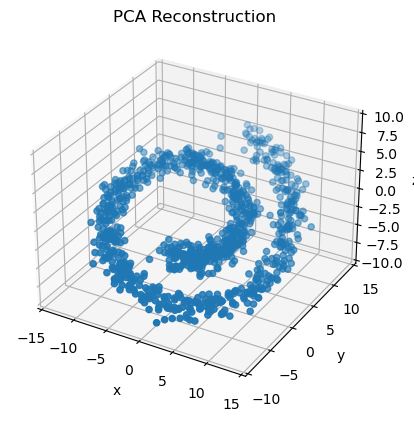

In [31]:
rec = pca.inverse_transform(encoding)
plot_data(points=rec, title="PCA Reconstruction", **set_kwargs)